<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/gymnasium/001-solving-cartpole_v1-with-reinforce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving CartPole-v1 with REINFORCE 🤖🎮

This notebook solves the [Gymnasium CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment using **REINFORCE** (Vanilla Policy Gradient) 🎮. **REINFORCE** is:

- **Policy-based:** Learns a policy directly, unlike value-based methods (e.g., **DQN**). 📈
- **On-policy:** The policy being learned interacts with the environment. 🌍
- **Model-free:** Requires no knowledge of environment dynamics. ❓
- **Monte Carlo:** Updates the policy at the end of an episode, unlike **Temporal Difference (TD)** methods. ⏳

## Setup 🛠️

First, let's install the necessary tools: 🛠️✨

In [29]:
!pip install gymnasium # The gymnasium environment
!pip install tsilva-notebook-utils # Personal utils to help with notebook authoring

Here are the key settings we'll use. 🔑 You can explore their meanings later 📖 after completing the notebook 📝 to improve your results. 📈

In [30]:
ENVIRONMENT_ID = "CartPole-v1" # The environment we want to solve
DISCOUNT_FACTOR = 0.99  # Discount factor controls how much we value future rewards
HIDDEN_SIZE = 128  # Neural network hidden layer size (128 gives enough capacity without overfitting)
LEARNING_RATE = 0.002  # Learning rate for optimizer (0.002 is a safe middle ground for small networks)
N_TRAIN_EPISODES = 5_000  # Total training episodes (5k should be more than enough)
AVERAGE_REWARD_WINDOW = 10  # Episodes required for calculating average reward

## Inspect Environment 🔍🌍

Set up the environment 🌍 and take a look 👀:

In [31]:
import gymnasium as gym
env = gym.make(ENVIRONMENT_ID, render_mode="rgb_array")
env.observation_space.shape, env.action_space

((4,), Discrete(2))

Observations (states) consist of `4` numbers 🔢, while actions are `0` or `1` ⚖️. The [docs](https://gymnasium.farama.org/environments/classic_control/cart_pole/) detail these numbers 📚, but it's not crucial since the reinforcement learning algorithm can solve the environment regardless 💪.

Let's check what is the reward threshold for this environment to be considered as solved:

In [32]:
AVERAGE_REWARD_THRESHOLD = env.spec.reward_threshold
AVERAGE_REWARD_THRESHOLD

475.0

If we average the cumulative reward for a significant number of episodes, and it's above the average reward threshold defined above, we can consider the episode as solved.

Let's run the environment for one episode 🎮 using a random policy to observe its behavior 👀:

In [33]:
import numpy as np
from tsilva_notebook_utils.video import render_video

# Define random policy
policy = lambda state: env.action_space.sample()

# Reset environment
state, _ = env.reset()

# Run environment step by step until
# it communicates it has finished
rewards = []
frames = []
done = False
while not done:
    # Render current state and collect frame
    frame = env.render()
    frames.append(frame)

    # Get next action from policy
    action = policy(state)

    # Execute action in environment
    next_state, reward, terminated, truncated, _ = env.step(action)

    # Determine if the environment
    # has finished (eg: pole fell,
    # cartpole went off the screen)
    done = terminated or truncated
    state = next_state

    # Collect reward
    rewards.append(reward)

# Log total reward
print(f"Sample rewards: {rewards[:5] + rewards[:-5]}")
print(f"Total Reward: {np.array(rewards).sum()}")

# Render collected environment frames as video
render_video(frames)

Sample rewards: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Total Reward: 24.0


Spoiler: it's bad. 😟 The pole falls quickly because random actions aren't sufficient. You earn a `1.0` reward per step until it crashes, and to win, you must last **500** steps. ⏳ Now that we've observed the poor performance of a random policy, let's explore how **REINFORCE** can train a more effective one. 🚀

## Enter REINFORCE   🤔✨

The goal of REINFORCE is to train a model to take better actions by maximizing a reward function. This function should consider two things:  

1. **How good each action was** (Did it lead to a high reward?)  
2. **How confident the model was when taking that action** (Did it assign a high probability to it?)  

The best possible outcome happens when the model always picks the best actions with 100% confidence.  

To model this reward function, we follow these steps:  

1. **Calculate the return for each step:**  
   - The return is the total reward the model expects from each step onward.  
   - Since we're doing this at the end of an episode, we can work backward, adding up rewards from the last step to the first.  

2. **Adjust returns based on action probability:**  
   - Multiply each step's return by how confident the model was in choosing that action.  
   - If the model picked a high-reward action by luck (low confidence), its impact will be reduced.  
   - This encourages the model to become more confident in choosing actions that consistently lead to high rewards.  

Now that we have our reward function, we need to optimize the model using backpropagation and gradient descent. However, gradient descent **minimizes** a loss function, while we want to **maximize** our reward.  

**Solution:** We simply **negate** the reward function to turn it into a loss function. This way, minimizing the loss increases the reward, improving the model's performance over time.  

## Create Policy Model 📄✨

To train a policy with **REINFORCE** 🎮, we need a model that adjusts based on policy performance (episode reward) 🏆. **Neural Networks** 🧠 with **Backpropagation** 🔄 and **Gradient Descent** 📉 are suitable for this. By defining a loss function that increases with poor performance 📈, these techniques adjust the model's parameters to reinforce good actions 👍 and decrease bad ones 👎 in future episodes.

Let's create the **Neural Network** 🤖 that will encode the policy we want to learn 📜:

In [34]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()

        # Create a multilayer perceptron with just one hidden layer
        self.net = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE), # Hidden layer (observation_space_size, hidden_layer_size)
            nn.ReLU(), # ReLU activation (for be able to model a non-linear functions)
            nn.Linear(HIDDEN_SIZE, action_dim) # Output layer (hidden_layer_size, action_space_size)
        )

    def forward(self, x):
        return self.net(x)

input_size = env.observation_space.shape[0]
output_size = env.action_space.n
model = PolicyNetwork(input_size, output_size)
model

PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

This environment features a low-dimensional continuous observation space 🌌 and a small discrete action space 🎮, allowing our **Neural Network** 🤖 to be a simple **Multilayer Perceptron** 🧠 with one hidden layer.  

It takes **4** observation values as input 🔍 and outputs **2** logits 📊, indicating the quality of each action in a given state.  

Let's test it by running an observation through the network 🚀:

In [35]:
with torch.no_grad(): # Don't track gradients during inference
  action_logits = model(torch.tensor(state)) # State is a numpy object, needs to be converted to tensor first
action_logits

tensor([0.1295, 0.4663])

The higher the logit for an action 📈, the more confident the model is that the action should be taken in that state 🤔. However, since the model is untrained 🚫, these logits are currently random 🎲.

Logits alone aren't ideal. While they indicate the "best" action, we don't always want the highest score, as the model doesn't initially know the best actions. Instead, we want to **sample** from possible actions, favoring those the model is more confident in. 🎲

This approach balances **exploration and exploitation**:  
- It allows the model to try less-favored actions, potentially leading to **unexpectedly high rewards** 🎉 and further learning.  
- It ensures the model **leans toward the best-known actions** while refining its understanding over time. 📈

To sample actions based on the model's confidence 🤖, we convert logits into a probability distribution 📊 (values from `0.0` to `1.0` that sum to `1.0`) using the `softmax()` function:

In [36]:
action_probs = torch.softmax(action_logits, dim=-1) # Dim = -1 means the last dimension of the tensor, Dim = 0 would also work in this case
action_probs, action_probs.sum()

(tensor([0.4166, 0.5834]), tensor(1.))

Now, let's sample an action: 🎬✨

In [37]:
action = torch.multinomial(action_probs, 1).item() # Sample 1 action from the probability distribution
action

1

You can run the cell above multiple times 🔄 to get different actions 🎭. The action with the highest logit 📈 will appear more frequently 🔍.

## Model the Loss Function 📉✨

Now, let's design the loss function step-by-step: 🛠️

**Step 1: Compute Returns** 📈

To construct the loss function, compute the return for each step as the immediate reward 💰 plus discounted future rewards. Distant rewards should contribute less to the total return due to their uncertainty. 🌌

**Step 2: Normalize** ✨

Normalize returns by subtracting the mean $\mu$ 📉 and dividing by the standard deviation $\sigma$ 📊. This keeps training stable ⚖️ by emphasizing relative performance over varying absolute reward scales. 🌟

**Step 3: Scale with Log Probs** 📈

We scale returns by the policy's confidence using the logarithm of probabilities instead of raw probabilities. Logarithms amplify small probabilities, making their values more negative as probabilities approach zero.

- **Big return, high confidence:**
  - Raw return was `100`.
  - The normalized return is `2`.
  - Action was taken with `90%` confidence.
  - The log probability is `log(0.9) = -0.1`.
  - Adjusted return is `2 * -0.1 = -0.2`.
  - The policy is nudged to reinforce this trusted action. 👍
- **Big return, low confidence:**
  - Raw return `100`, which normalizes to `2`.
  - Action was taken with `0.1%` confidence, so `log(0.001) = -6.9`.
  - Adjusted return is `2 * -6.9 = -13.8`.
  - The large negative log reduces the fluke's impact, preventing overreaction. 🚫
- **Bad return, low confidence:**
  - Raw return `-50` normalizes to `-1`.
  - Action was taken with `0.1%` confidence.
  - The log probability is `log(0.001) = -6.9`.
  - Adjusted return is `-1 * -6.9 = 6.9`.
  - The update is small, reflecting the action's rarity. 🔍
- **Bad return, high confidence:**
  - Raw return was `-50`, which normalizes to `-1`.
  - Action was taken with `90%` confidence.
  - The log probability is `log(0.9) = -0.1`.
  - Adjusted return is `-1 * -0.1 = 0.1`.
  - The policy adjusts slightly, reconsidering a trusted action that resulted in a poor outcome, with a smaller update due to high confidence. ⚖️

**Step 4: Calculate the Reward Function** 📉

To calculate the reward function we just have to calculate the mean of the scaled returns.

**Step 5: Calculate the Loss Function**

To calculate the loss function, we just have to negate the reward function. This way, when the model is being optimized with **gradient descent**, as the loss is pushed down through the optimization process, the reward function will go up, because they are the opposite.

Now that we know how to build our loss function, let's proceed step by step. 🛠️ First, we need to collect the rewards 🎉 and action log probabilities 📊 for an episode:

In [38]:
def run_episode(env, policy, train_mode=False):
    # Reset the environment
    state, _ = env.reset()

    # Run environment until it
    # communicates that it has finished
    done = False
    rewards = []
    action_logprobs = []
    frames = []
    while not done:
        # Render frame
        frame = env.render()
        frames.append(frame)

        # Predict action probabilities using the model
        with torch.no_grad() if not train_mode else torch.enable_grad():
            action_logits = policy(torch.tensor(state))
            action_probs = torch.softmax(action_logits, dim=-1)
            action = torch.multinomial(action_probs, 1).item()

        # Collect action log probabilities
        action_prob = action_probs[action]
        action_log_prob = torch.log(action_prob)
        action_logprobs.append(action_log_prob)

        # Step the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store reward and update state
        rewards.append(reward)
        state = next_state

    return rewards, action_logprobs, frames

# Run an episode
rewards, action_logprobs, _ = run_episode(env, model)
rewards[:5], action_logprobs[:5]

([1.0, 1.0, 1.0, 1.0, 1.0],
 [tensor(-0.6547),
  tensor(-0.7359),
  tensor(-0.7348),
  tensor(-0.6394),
  tensor(-0.7363)])

Now we can calculate the returns 📈 for each step 🔢 without normalizing them yet:

In [39]:
def calculate_returns(rewards, discount_factor=DISCOUNT_FACTOR, normalize=True):
    # Initialize returns tensor (same shape as rewards)
    returns = torch.zeros(len(rewards))

    # Return for each step is the reward for that step
    # plus the discounted return for the next step
    # (calculated from last to first step)
    for t in range(len(returns)-1, -1, -1):
      returns[t] = rewards[t] + discount_factor * (returns[t+1] if t < len(returns)-1 else 0)

    # To normalize values so that they match a normal distribution
    # we only have to subtract the mean of the values and divide by
    # the standard deviation
    if normalize: returns = (returns - returns.mean()) / (returns.std() + 1e-8) # NOTE: we add a small value to std() because it can be zero when all values are the same

    # Return the returns :)
    return returns

calculate_returns(rewards, normalize=False)

tensor([40.7034, 40.1044, 39.4994, 38.8883, 38.2710, 37.6475, 37.0176, 36.3815,
        35.7388, 35.0897, 34.4341, 33.7718, 33.1028, 32.4271, 31.7445, 31.0551,
        30.3587, 29.6552, 28.9447, 28.2269, 27.5020, 26.7697, 26.0300, 25.2828,
        24.5281, 23.7657, 22.9957, 22.2179, 21.4322, 20.6386, 19.8369, 19.0272,
        18.2093, 17.3831, 16.5486, 15.7057, 14.8542, 13.9942, 13.1254, 12.2479,
        11.3615, 10.4662,  9.5618,  8.6483,  7.7255,  6.7935,  5.8520,  4.9010,
         3.9404,  2.9701,  1.9900,  1.0000])

Earlier timesteps yield higher returns 📈 as they incorporate discounted rewards from future steps. In contrast, returns decrease 📉 throughout the episode, reaching `1.0` at the final step, reflecting only the immediate reward 🎯.

This pattern of diminishing returns may not always be linear. In this simple environment 🌱, with a consistent immediate reward of `1.0`, the progression is clear. However, in more complex environments 🌪️ with varying reward magnitudes and polarities—large or small, positive or negative—the return dynamics differ significantly.

Now let's recalculate the returns with normalization 📊✨:

In [40]:
returns = calculate_returns(rewards)
returns

tensor([ 1.5452,  1.4943,  1.4429,  1.3910,  1.3386,  1.2857,  1.2322,  1.1782,
         1.1236,  1.0685,  1.0128,  0.9566,  0.8998,  0.8424,  0.7844,  0.7259,
         0.6667,  0.6070,  0.5467,  0.4857,  0.4242,  0.3620,  0.2992,  0.2357,
         0.1716,  0.1069,  0.0415, -0.0246, -0.0913, -0.1587, -0.2267, -0.2955,
        -0.3650, -0.4351, -0.5060, -0.5776, -0.6499, -0.7229, -0.7967, -0.8712,
        -0.9464, -1.0225, -1.0993, -1.1768, -1.2552, -1.3344, -1.4143, -1.4951,
        -1.5766, -1.6590, -1.7422, -1.8263])

Don't worry about negative numbers ➖; the relative scale of rewards 🎁 remains intact. What matters is the direction of the return ⬆️, not the sign.

We need to format the action log probabilities to match the returns—a 1D tensor of the same length 📏. Currently, they are stored as a list of tensors 📋. We can convert them into a single tensor by concatenating with `torch.stack()` 🔗:

In [41]:
stacked_action_logprobs = torch.stack(action_logprobs)
stacked_action_logprobs

tensor([-0.6547, -0.7359, -0.7348, -0.6394, -0.7363, -0.6373, -0.6500, -0.6477,
        -0.7409, -0.7431, -0.6456, -0.6440, -0.7443, -0.6422, -0.7460, -0.7481,
        -0.6404, -0.6405, -0.7477, -0.6399, -0.7485, -0.6397, -0.7489, -0.7492,
        -0.7494, -0.6270, -0.6417, -0.6416, -0.7474, -0.7472, -0.7458, -0.6298,
        -0.6446, -0.7455, -0.6452, -0.7451, -0.6458, -0.6441, -0.6437, -0.6471,
        -0.7367, -0.6472, -0.6502, -0.7465, -0.7400, -0.7351, -0.7401, -0.7328,
        -0.7214, -0.6660, -0.6704, -0.6643])

Let's confirm that **returns** 📈 and **action log probabilities** 📊 share the same shape:

In [42]:
returns.shape, stacked_action_logprobs.shape

(torch.Size([52]), torch.Size([52]))

They have the same shape 🔷, allowing us to scale the returns 📈:

In [43]:
scaled_returns = stacked_action_logprobs * returns
scaled_returns

tensor([-1.0117, -1.0996, -1.0603, -0.8894, -0.9857, -0.8193, -0.8010, -0.7631,
        -0.8325, -0.7940, -0.6538, -0.6160, -0.6697, -0.5410, -0.5851, -0.5431,
        -0.4270, -0.3888, -0.4087, -0.3108, -0.3175, -0.2316, -0.2240, -0.1766,
        -0.1286, -0.0670, -0.0266,  0.0158,  0.0682,  0.1186,  0.1691,  0.1861,
         0.2353,  0.3244,  0.3265,  0.4304,  0.4197,  0.4656,  0.5128,  0.5638,
         0.6972,  0.6617,  0.7148,  0.8786,  0.9289,  0.9809,  1.0467,  1.0956,
         1.1374,  1.1049,  1.1680,  1.2132])

With the scaled returns 📈, we can now calculate the episode's mean return 📊, which our policy aims to maximize 🎯:

In [44]:
mean_return = torch.mean(scaled_returns)
mean_return

tensor(0.0018)

Finally, we negate the mean return to obtain the policy loss. **Gradient descent** aims to minimize loss, which correlates with improving our policy 📈. By negating the mean return, we create a term that, when minimized, enhances the mean return 🌟.

In [45]:
policy_loss = -1.0 * mean_return
policy_loss

tensor(-0.0018)

Let's create a loss calculation function for use during training: 📊🤖

In [46]:
def calculate_policy_loss(rewards, action_logprobs, baseline=0.0):
    # Calculate returns
    returns = calculate_returns(rewards)

    # Subtract baseline to reduce variance
    returns = returns - baseline

    # Stack action log probabilities and scale returns
    stacked_action_logprobs = torch.stack(action_logprobs)
    scaled_returns = stacked_action_logprobs * returns

    # Calculate policy loss
    mean_return = torch.mean(scaled_returns)
    policy_loss = -mean_return

    return policy_loss

calculate_policy_loss(rewards, action_logprobs)

tensor(-0.0018)

Now that we can calculate the loss 📉, we will run the training loop 🔄 and adjust the policy 📝 using backpropagation 🔙 and gradient descent optimization ⬇️.

## Train Policy 🚆📜

In [47]:
import time
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tsilva_notebook_utils.video import render_video

def train(model, n_episodes=N_TRAIN_EPISODES, baseline_window=50):
  # Set the model in training mode
  model.train()

  # Create the optimizer that will adjust the policy
  # model's parameters to minimize policy loss
  optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

  baseline_buffer = []  # Store recent returns for baseline calculation

  # Run training for N episodes
  start = time.time()
  episode_rewards = []
  episode_policy_losses = []
  for episode in range(N_TRAIN_EPISODES):
      # Run the episode (enable train mode to track gradients)
      rewards, action_logprobs, frames = run_episode(env, model, train_mode=True)

      # Update baseline buffer (moving average over baseline_window episodes)
      total_reward = np.array(rewards).sum()
      baseline_buffer.append(total_reward)
      if len(baseline_buffer) > baseline_window:
          baseline_buffer.pop(0)  # Keep only the last `baseline_window` rewards
      baseline = np.mean(baseline_buffer) if baseline_buffer else 0.0

      # Calculate the policy loss
      policy_loss = calculate_policy_loss(rewards, action_logprobs, baseline=baseline)

      # Zero out the gradients (otherwise they would
      # accumulate between optimization steps)
      optimizer.zero_grad()

      # Perform backpropagation to calculate policy model
      # parameter gradients, which inform on how to tweak
      # parameters to reduce loss, capturing both direction and scale
      policy_loss.backward()

      # Perform an optimization step, using gradients calculated
      # during backpropagation to adjust model parameters in the direction
      # that is likely to make the loss smaller (adjustment is scaled
      # down by magnitude of learning rate)
      optimizer.step()

      # Store total reward to plot at end of training
      episode_rewards.append(total_reward)
      episode_policy_losses.append(policy_loss.item())

      # Every N episodes, calculate the average reward of those episodes,
      # if it passes a threshold, the environment is considered to be solved
      # (NOTE: we need to make sure the average is above the threshold to
      # discount for episodes where the policy was just lucky)
      if (episode + 1) % AVERAGE_REWARD_WINDOW == 0:
          avg_reward = np.mean(episode_rewards[-AVERAGE_REWARD_WINDOW:])
          print(f"Episode {episode + 1}, Avg Reward: {avg_reward}, Policy Loss: {policy_loss.item()}")
          if avg_reward >= AVERAGE_REWARD_THRESHOLD:
              break

  # Close environment
  env.close()

  # Print final stats
  elapsed = time.time() - start
  print(f"Environment solved in {episode} episodes ({elapsed:.2f} seconds)")

  return episode_rewards, episode_policy_losses

# Train the policy model
episode_rewards, episode_policy_losses = train(model)
episode_rewards[:3] + ["..."] + episode_rewards[-3:]
episode_policy_losses[:3] + ["..."] + episode_policy_losses[-3:]

Episode 10, Avg Reward: 23.7, Policy Loss: -16.50090217590332
Episode 20, Avg Reward: 21.3, Policy Loss: -15.58603572845459
Episode 30, Avg Reward: 21.6, Policy Loss: -14.989678382873535
Episode 40, Avg Reward: 26.7, Policy Loss: -16.162158966064453
Episode 50, Avg Reward: 21.4, Policy Loss: -15.527664184570312
Episode 60, Avg Reward: 27.1, Policy Loss: -15.82634449005127
Episode 70, Avg Reward: 33.4, Policy Loss: -17.314720153808594
Episode 80, Avg Reward: 20.9, Policy Loss: -17.312740325927734
Episode 90, Avg Reward: 30.2, Policy Loss: -17.39259910583496
Episode 100, Avg Reward: 20.3, Policy Loss: -16.546100616455078
Episode 110, Avg Reward: 16.1, Policy Loss: -15.916289329528809
Episode 120, Avg Reward: 32.9, Policy Loss: -15.231365203857422
Episode 130, Avg Reward: 32.1, Policy Loss: -16.462053298950195
Episode 140, Avg Reward: 44.8, Policy Loss: -23.45729637145996
Episode 150, Avg Reward: 39.7, Policy Loss: -21.25425148010254
Episode 160, Avg Reward: 48.8, Policy Loss: -23.2234001

[-36.8864860534668,
 -27.264780044555664,
 -22.95730972290039,
 '...',
 -212.46771240234375,
 -209.27281188964844,
 -217.85491943359375]

Our model is trained 🎓; let's plot the training progress 📈:

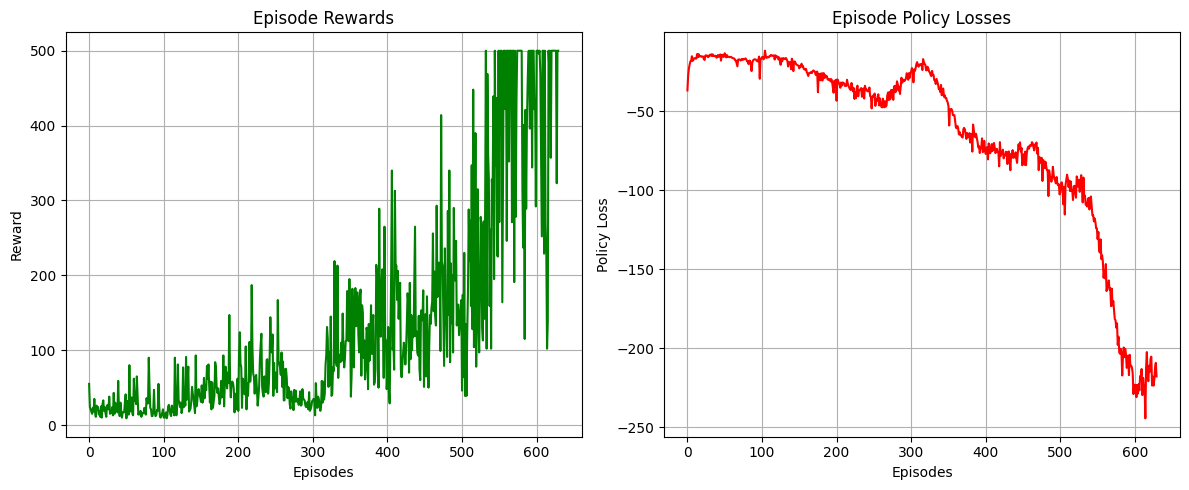

In [50]:
def plot_episode_rewards_and_losses(episode_rewards, episode_policy_losses):
    plt.figure(figsize=(12, 5))  # Wider figure to accommodate two plots

    # First subplot for rewards (left)
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
    plt.xlabel('Episodes')
    plt.ylabel('Reward')
    plt.grid(True)
    plt.plot(episode_rewards, color='green')  # Set rewards to green
    plt.title('Episode Rewards')

    # Second subplot for policy losses (right)
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
    plt.xlabel('Episodes')
    plt.ylabel('Policy Loss')
    plt.grid(True)
    plt.plot(episode_policy_losses, color='red')  # Set policy losses to red
    plt.title('Episode Policy Losses')

    plt.tight_layout()  # Adjusts spacing between plots
    plt.show()

plot_episode_rewards_and_losses(episode_rewards, episode_policy_losses)

We stopped upon reaching our reward threshold 🎯 due to the training process's instability. Continuing could lead to suboptimal behaviors ⚠️ and performance degradation 📉. To train longer while mitigating this risk, we should save model snapshots 💾 whenever a new best reward is achieved 🏆, allowing us to revert to the best-performing version at the end of training 🔄.

## Evaluate Policy 📊📝

A good reward during training isn't sufficient; the real test is running the trained policy multiple times in the environment 🌍 to check reward consistency. Averaging these rewards 📊 is the true measure of the policy's effectiveness.

In [49]:
from IPython.display import clear_output

def evaluate(model, n_episodes=10):
    # Set the model in evaluation mode
    model.eval()

    # Run evaluation for N episodes
    episode_rewards = []
    for episode in range(n_episodes):
        rewards, action_logprobs, frames = run_episode(env, model, train_mode=True)
        episode_reward = np.array(rewards).sum()
        episode_rewards.append(episode_reward)
        print(f"Episode {episode+1} Reward: {episode_reward}")

    # Print final stats
    mean_reward = np.mean(episode_rewards)
    print(f"Mean reward over {n_episodes} episodes: {mean_reward}")

    # Return stats and frames (for rendering)
    return mean_reward, frames

_, frames = evaluate(model, n_episodes=10)
render_video(frames)

Episode 1 Reward: 500.0
Episode 2 Reward: 500.0
Episode 3 Reward: 500.0
Episode 4 Reward: 500.0
Episode 5 Reward: 500.0
Episode 6 Reward: 500.0
Episode 7 Reward: 500.0
Episode 8 Reward: 500.0
Episode 9 Reward: 500.0
Episode 10 Reward: 500.0
Mean reward over 10 episodes: 500.0


## Further Improvements 🚀✨

And we're done! 🎉 To optimize the algorithm, consider these experiments:

- **Increase `LEARNING_RATE`**: Set it to `0.01` to speed up training—observe if rewards increase faster. 🚀
- **Decrease `LEARNING_RATE`**: Lower it to `0.001` for more cautious updates—see how it stabilizes the learning curve. 📉
- **Modify `DISCOUNT_FACTOR`**: Use `0.95` to prioritize short-term rewards—plot the results to notice changes. 📊
- **Enhance `HIDDEN_SIZE`**: Raise it to `256` for a stronger network—test its performance on the pole. 🏋️‍♂️
- **Implement a baseline**: Subtract the average return from past episodes from `returns` before scaling to reduce variability. ⚖️
- **Explore different environments**: Run the codebase in similar environments like:
  - [Acrobot-v1](https://gymnasium.farama.org/environments/classic_control/acrobot/) 🤖
  - [MountainCar-v0](https://www.gymlibrary.dev/environments/classic_control/mountain_car/) ⛰️
  - [LunarLander-v3](https://www.gymlibrary.dev/environments/box2d/lunar_lander/) 🌕
  - [Blackjack-v1](https://www.gymlibrary.dev/environments/toy_text/blackjack/) ♠️
  - [FrozenLake-v1](https://www.gymlibrary.dev/environments/toy_text/frozen_lake/) ❄️

Adjust these parameters one at a time, rerun the code, and discover your optimal setup! 🔍✨